For a proof of concept pitch, you do not need real predictions. You need the *illusion of a working system* — real enough that an investor or client understands what the full product does and why it matters. The goal is to make them say "I get it" and "I want this," not to actually build the engine.

---

**The prototype has one job**

Show someone a piece of content, show them what the tool says about it, and make the diagnosis feel credible and useful. That is the entire pitch. Everything else is decoration.

---

**Day 1 — Get your data layer working (2–3 hours)**

Pull real Google Trends data using pytrends for two or three topics relevant to Imane's niche. Pull her last 20–30 Instagram posts if she can export them, or use any public account's data as a placeholder. You now have two real datasets — trend signals and campaign history. Put them in a clean CSV or SQLite table. This is the only real data work in the prototype.

**Day 2 — Build the dashboard view (3–4 hours)**

Build a single Streamlit page that shows a line chart of trend velocity over time, overlaid with engagement rate from the campaign data. No model yet — just the overlay. This one visual alone is already a compelling story: you can see with your eyes that engagement peaks coincide with trend peaks. That is the core thesis of the product made visible in five minutes of looking.

Add a date filter and a topic selector so whoever is watching the demo can interact with it. Interactivity makes it feel real even when the backend is simple.

**Day 3 — Fake the prediction layer (2–3 hours)**

You do not need a trained XGBoost model for the demo. Build a rule-based scoring function in Python that takes a few inputs — current trend score, sentiment of the copy, posting day — and outputs a performance tier: High, Medium, or Low. The logic can be simple: if trend score is above a threshold and sentiment is positive, output High. It does not matter. What matters is that the interface looks like a model is running.

Add a simple form to the Streamlit app: a text box for the post copy, a date picker, a dropdown for content format. When you hit "Analyse," it outputs the tier and three bullet points explaining why. Those bullet points can be hardcoded for the demo — pick the three most compelling diagnostic outputs and always show them. Nobody will know.

**Day 4 — Make it look like a product (2–3 hours)**

Add a logo placeholder, a clean colour scheme, and a simple two-page structure: Page 1 is the dashboard (historical performance + trend overlay). Page 2 is the prediction tool (submit content, get a score and diagnosis). That navigation alone makes it feel like software rather than a script.

Deploy it on Streamlit Cloud. It is free and takes fifteen minutes. The fact that it has a URL you can share is psychologically significant in a pitch — it is not a screenshot, it is a thing that exists on the internet.

**Day 5 — Prepare the pitch narrative (1–2 hours)**

The demo needs a story arc. You show the dashboard first and say: "This is what your last 30 posts look like against what was trending when you posted them. You can see the gap." Then you switch to the prediction tool and say: "This is what we do with that information. Before you post, you run it through here." You submit a real piece of planned content live in the room. The tool outputs a score and a diagnosis. You say: "That diagnosis is what no other tool gives you."

Total time: roughly 12–15 hours across five days.

---

**What you are not building**

You are not building a real model, a database, an automated pipeline, a user login system, or a multi-client architecture. All of that comes later. If anyone asks how the prediction works, you say it uses a gradient-boosted model trained on historical campaign data and trend signals — which is true of the real version — and you move the conversation forward. You are selling the vision, not the engine.

---

**After the demo lands**

If Imane responds well, you use her real data to replace the mock data and the rule-based scoring with an actual LightGBM model. That is your Stage 1 to Stage 3 transition, and now you have a client and a case study driving it rather than building in a vacuum.

In [2]:
import requests
import pandas as pd 
from pytrends.request import TrendReq
import matplotlib.pyplot as plt


In [ ]:
# pytrends = TrendReq(hl='en-US', tz=360)
# keyword_list = ["war"]
# pytrends.build_payload(keyword_list)
# iot = pytrends.interest_over_time()
# # iot.plot()
# iot

TooManyRequestsError: The request failed: Google returned a response with code 429

/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnin

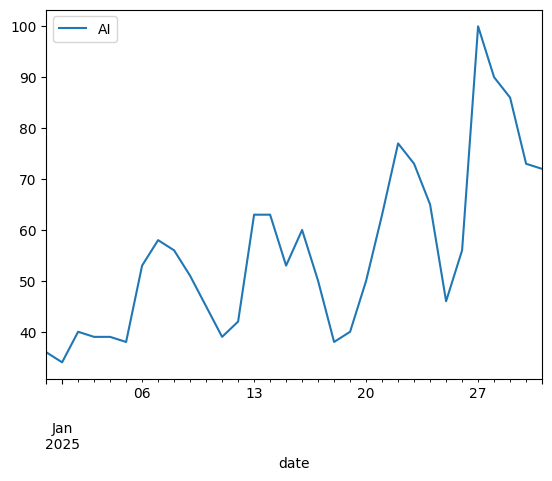

,AI,isPartial
date,,
2024-12-31,36,False
2025-01-01,34,False
2025-01-02,40,False
2025-01-03,39,False
2025-01-04,39,False
2025-01-05,38,False
2025-01-06,53,False
2025-01-07,58,False
2025-01-08,56,False


In [4]:
pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25), 
                    # proxies=['https://34.203.233.13:80',], retries=2, backoff_factor=0.1, 
                    requests_args={'verify':False})
# Note: the parameter hl specifies host language for accessing Google Trends
keyword_list = ["AI"]
pytrends.build_payload(keyword_list, cat=0, timeframe='2024-12-31 2025-01-31', geo='', gprop='news')
trend_data = pytrends.interest_over_time()

# cat
#     Category to narrow results
#     Find available categories by inspecting the url when manually using Google Trends. 

#geo Two letter country abbreviation
    # For example United States is 'US'
    # Defaults to World
    # More detail available for States/Provinces by specifying additional abbreviations
    # For example: Alabama would be 'US-AL'
    # For example: England would be 'GB-ENG'

# timeframe
    #     Date to start from
    #     Defaults to last 5yrs, 'today 5-y'.
    #     Everything 'all'
    #     Specific dates, 'YYYY-MM-DD YYYY-MM-DD' example '2016-12-14 2017-01-25'

trend_data.plot()
plt.show()
trend_data


In [5]:
trend_data.tail()

,AI,isPartial
date,,
2025-01-27,100,False
2025-01-28,90,False
2025-01-29,86,False
2025-01-30,73,False
2025-01-31,72,False


In [6]:
trend_data['velocity_rolling'] = trend_data['AI'].diff().rolling(3).mean()
trend_data.head(15)

,AI,isPartial,velocity_rolling
date,,,
2024-12-31,36,False,NaN
2025-01-01,34,False,NaN
2025-01-02,40,False,NaN
2025-01-03,39,False,1.000000
2025-01-04,39,False,1.666667
2025-01-05,38,False,-0.666667
2025-01-06,53,False,4.666667
2025-01-07,58,False,6.333333
2025-01-08,56,False,6.000000


<Axes: xlabel='date'>

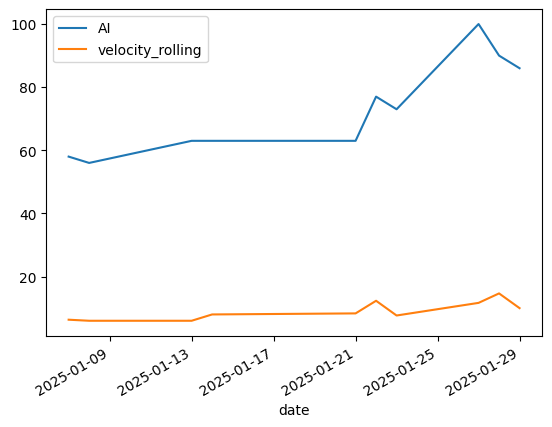

In [7]:
high_velocity_trends = trend_data[trend_data["velocity_rolling"] >= 6]
trend_data['acceleration'] = trend_data['velocity_rolling'].diff()
high_velocity_trends.plot()

Text(0.5, 1.0, 'AI Trend: Signal Strength vs Velocity')

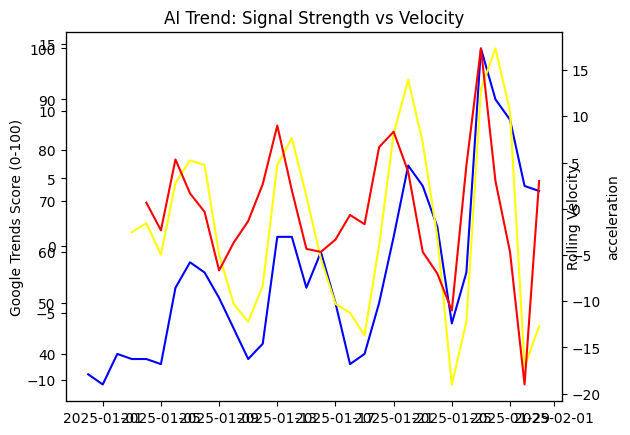

In [8]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()  # second y-axis
ax3 = ax2.twinx()

ax1.plot(trend_data.index, trend_data['AI'], color='blue', label='AI')
ax2.plot(trend_data.index, trend_data['velocity_rolling'], color='yellow', label='Velocity')
ax3.plot(trend_data.index, trend_data['acceleration'], color='red', label='acceleration')


ax1.set_ylabel('Google Trends Score (0-100)')
ax2.set_ylabel('Rolling Velocity')
ax3.set_ylabel("acceleration")
plt.title('AI Trend: Signal Strength vs Velocity')

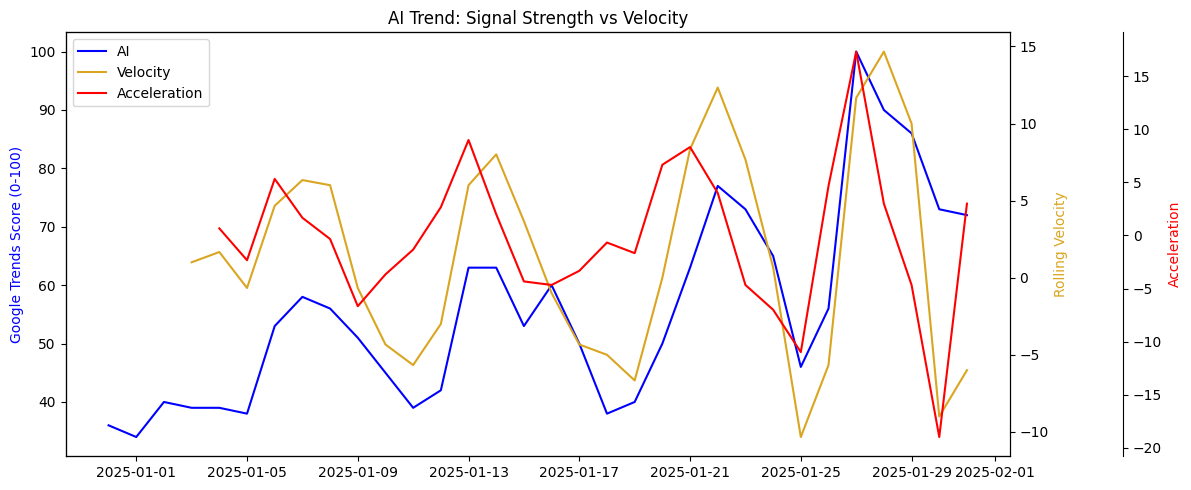

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Push ax3's spine further right so it doesn't overlap ax2
ax3.spines['right'].set_position(('axes', 1.12))

l1, = ax1.plot(trend_data.index, trend_data['AI'], color='blue', label='AI')
l2, = ax2.plot(trend_data.index, trend_data['velocity_rolling'], color='goldenrod', label='Velocity')
l3, = ax3.plot(trend_data.index, trend_data['acceleration'], color='red', label='Acceleration')

ax1.set_ylabel('Google Trends Score (0-100)', color='blue')
ax2.set_ylabel('Rolling Velocity', color='goldenrod')
ax3.set_ylabel('Acceleration', color='red')

# Combine all legends into one
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('AI Trend: Signal Strength vs Velocity')
plt.tight_layout()
plt.show()

In [10]:
# pytrends.build_payload(kw_list=['Linux', 'Ubuntu'] ,timeframe=['2022-09-04 2022-09-10', '2022-09-18 2022-09-24'])
# multirange_IOT = pytrends.multirange_interest_over_time() #Interest Over time
# multirange_IOT.plot()

# Z-Score


In [11]:
trend_data

,AI,isPartial,velocity_rolling,acceleration
date,,,,
2024-12-31,36,False,NaN,NaN
2025-01-01,34,False,NaN,NaN
2025-01-02,40,False,NaN,NaN
2025-01-03,39,False,1.000000,NaN
2025-01-04,39,False,1.666667,0.666667
2025-01-05,38,False,-0.666667,-2.333333
2025-01-06,53,False,4.666667,5.333333
2025-01-07,58,False,6.333333,1.666667
2025-01-08,56,False,6.000000,-0.333333


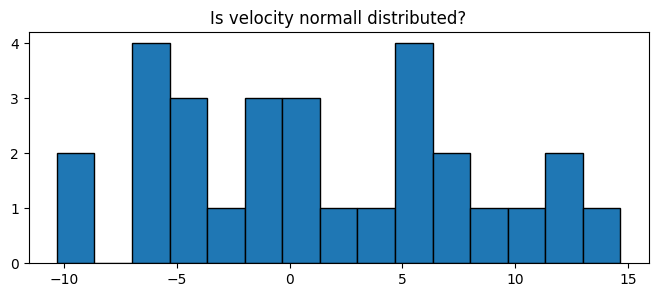

Shapiro-Wilk p-value: 0.5127
✅ Looks normal — z-score is valid


In [12]:
## Checking for normality of distribution

from scipy.stats import shapiro, normaltest
# normaltest specifically checks two things about your data's shape:
    # Skewness — is it lopsided left or right?
    # Kurtosis — are the tails too fat or too thin?


velocity = trend_data["velocity_rolling"].dropna()

# Visual Check 
plt.figure(figsize=(8,3))
plt.hist(velocity, bins= 15, edgecolor= "Black")
plt.title("Is velocity normall distributed?")
plt.show()

# Statistical test (Shapiro-Wilk — best for small samples)
stat, p = shapiro(velocity) 
# It returns a number between 0 and 1. The closer to 1, the more normal your data looks.

print(f"Shapiro-Wilk p-value: {p:.4f}")

if p > 0.05:
    print("✅ Looks normal — z-score is valid")
else:
    print("⚠️ Not normal — consider robust z-score")

## What is Z-score is not Normal?

***MAD (Median Absolute Deviation)***

**Here's the intuition. Normal standard deviation is sensitive to outliers, one massive spike pulls the average and makes everything look less extreme. MAD ignores that problem by using the median instead.**

Concretely:

Take all your velocity values

Find the median (middle value)

Calculate how far each value is from that median

The MAD is the median of those distances

**It's essentially asking: on a typical day, how far does velocity stray from the middle? That's your yardstick.**

In [13]:
from scipy.stats import median_abs_deviation

median = velocity.median()
mad = median_abs_deviation(velocity)

trend_data["velocity_zscore"] = (velocity - median )/ mad

In [14]:
from scipy.stats import norm

z = trend_data["velocity_zscore"].iloc[-1]

# One-tailed (we only care if velocity is unusually HIGH)
p_value = 1 - norm.cdf(z)

print(f"Z-score:  {z:.2f}")
print(f"P-value:  {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant — signal is real")
else:
    print("⚪ Not significant — could be noise")

Z-score:  -1.18
P-value:  0.8803
⚪ Not significant — could be noise


1. explain that does the keyword column the number mean when i get a df from pytrends 
2. do we need accelration? 
3. explain mathmatical concepts in an intuative way:
3.1 shapiro 
3.2 normal test - how did you convert it into a normal distribution 
3.3 what is velocity zscore, what is mad?
3.4 what is the p in shairo test and what is the p in z score, what's the difference 
3.5 what is norm, cdf, and z

### Velocity tells you: is the trend growing? 
### Acceraltion tells you if the growth is speeding up or slowing down
**Accelration can be useful in catching trends easily but it is a noisy signal**


In [15]:
accelration = trend_data["acceleration"].dropna()
median_acc = accelration.median()
mad = median_abs_deviation(accelration)

trend_data["accelration_zscore"] = (accelration - median )/ mad

z = trend_data["accelration_zscore"].iloc[-1]

# One-tailed (we only care if velocity is unusually HIGH)
p_value = 1 - norm.cdf(z)

print(f"Z-score:  {z:.2f}")
print(f"P-value:  {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant — signal is real")
else:
    print("⚪ Not significant — could be noise")

Z-score:  0.58
P-value:  0.2798
⚪ Not significant — could be noise


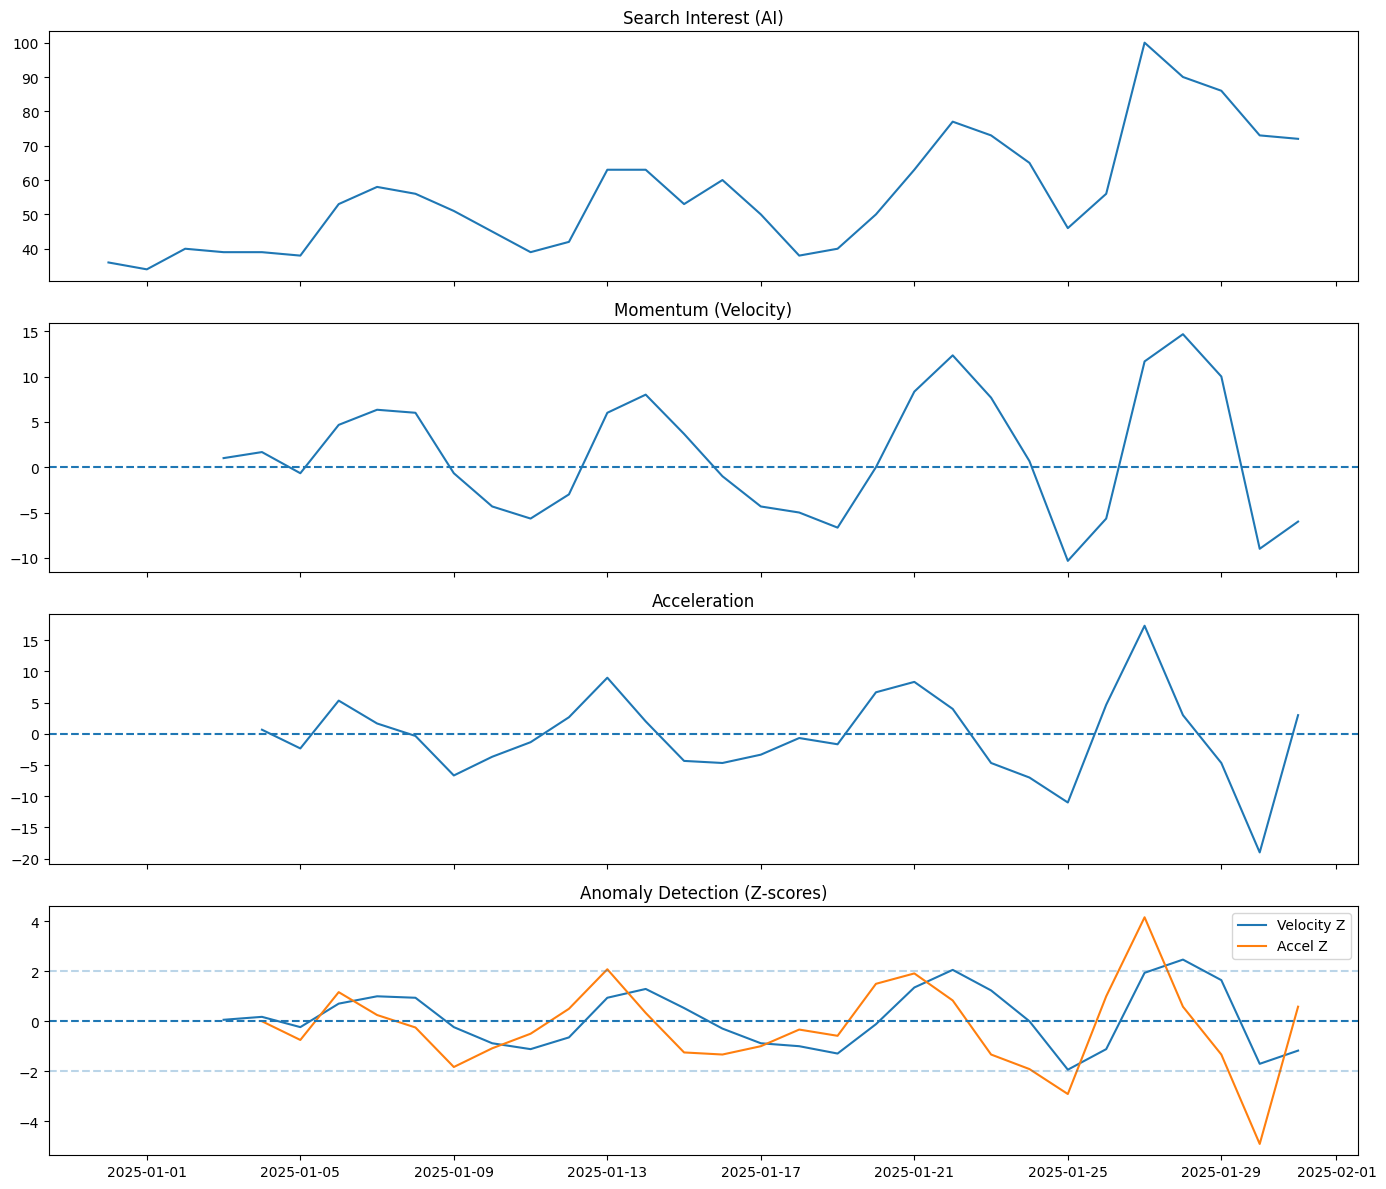

In [17]:
df = trend_data.copy()
import matplotlib.pyplot as plt

df = df.reset_index()
df = df.sort_values("date")

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# 1. Raw interest
axes[0].plot(df["date"], df["AI"])
axes[0].set_title("Search Interest (AI)")

# 2. Velocity
axes[1].plot(df["date"], df["velocity_rolling"])
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Momentum (Velocity)")

# 3. Acceleration
axes[2].plot(df["date"], df["acceleration"])
axes[2].axhline(0, linestyle="--")
axes[2].set_title("Acceleration")

# 4. Z-scores
axes[3].plot(df["date"], df["velocity_zscore"], label="Velocity Z")
axes[3].plot(df["date"], df["accelration_zscore"], label="Accel Z")
axes[3].axhline(0, linestyle="--")
axes[3].axhline(2, linestyle="--", alpha=0.3)
axes[3].axhline(-2, linestyle="--", alpha=0.3)
axes[3].legend()
axes[3].set_title("Anomaly Detection (Z-scores)")

plt.tight_layout()
plt.show()